# Student Dropout
##### The goal of this project is to predict student dropout based on demographic, academic, and lifestyle-related factors from the Student Dropout Prediction Dataset. The analysis includes data cleaning, preprocessing, exploratory data analysis, and the comparison of two classification models: Logistic Regression and XGBoost. The main objective is to identify which model performs better in predicting students at risk of dropping out.

## Data import
##### The dataset was downloaded using kagglehub and loaded into a pandas DataFrame for further analysis. After loading the file, the structure of the dataset was checked to confirm the available variables and prepare the data for preprocessing.

In [535]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE, SMOTENC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer


In [536]:
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /Users/janzawadzki/.cache/kagglehub/datasets/meharshanali/student-dropout-prediction-dataset/versions/1
['student_dropout_dataset_v3.csv']


In [537]:
file_path = os.path.join(path, 'student_dropout_dataset_v3.csv')
df = pd.read_csv(file_path)

## EDA
##### The exploratory data analysis focused on understanding the structure and quality of the dataset. Basic inspection methods were used to review data types, summary statistics, and missing values. Selected visualizations were also created to examine relationships between features and the target variable (Dropout), especially for variables that appeared to be most relevant to student dropout.

In [538]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [539]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [540]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [541]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [542]:
cols_to_impute = ["Family_Income", "Study_Hours_per_Day", "Stress_Index"]
knn_imputer = KNNImputer(n_neighbors=5)
df[cols_to_impute] = knn_imputer.fit_transform(df[cols_to_impute])

In [543]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income              0
Internet_Access            0
Study_Hours_per_Day        0
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index               0
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [544]:
df["Parental_Education"] = df["Parental_Education"].fillna("Unknown")

In [545]:
df.Parental_Education.value_counts()

Parental_Education
Bachelor       3949
High School    3072
Master         2003
Unknown         511
PhD             465
Name: count, dtype: int64

In [546]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [547]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.000000,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.000000,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.000000,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,38377.247474,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.000000,Yes,4.190000,75.7,1,23.0,No,No,7.000000,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [548]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [549]:
# df["Internet_Access"] = df["Internet_Access"].map({"Yes": 1, "No": 0})
# df["Part_Time_Job"] = df["Part_Time_Job"].map({"Yes": 1, "No": 0})
# df["Scholarship"] = df["Scholarship"].map({"Yes": 1, "No": 0})

cols = ["Internet_Access", "Part_Time_Job", "Scholarship"]

for i in cols:
    df[i] = df[i].map({"Yes": 1, "No": 0})

In [550]:
df["Semester"] = df["Semester"].map({"Year 1": 1, "Year 2": 2, "Year 3": 3, "Year 4": 4,})

In [551]:
df = pd.get_dummies(df, columns=["Department"], dtype=int)

In [552]:
# df["Parental_Education"] = df["Parental_Education"].map({
#     "Unknown": 0,
#     "High School": 1,
#     "Bachelor": 2,
#     "Master": 3,
#     "PhD": 4
# })

df = pd.get_dummies(df, columns=["Parental_Education"], dtype=int)

In [553]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD,Parental_Education_Unknown
0,1,22.1,1,25000.000000,1,3.360000,86.1,2,20.4,1,...,1,0,0,0,0,0,1,0,0,0
1,2,20.7,1,25000.000000,1,4.300000,68.0,2,44.0,0,...,0,0,0,1,0,1,0,0,0,0
2,3,22.4,1,40183.000000,1,4.400000,70.9,0,48.9,1,...,1,0,0,0,0,0,0,1,0,0
3,4,24.4,1,38377.247474,1,4.014592,82.2,2,38.6,0,...,0,0,1,0,0,0,1,0,0,0
4,5,20.5,0,25319.000000,1,4.190000,75.7,1,23.0,0,...,0,1,0,0,0,1,0,0,0,0


In [554]:
df.drop(columns='Student_ID', inplace=True)

## Model selection
##### At this stage, the goal was to better understand which features were most related to student dropout and to support the choice of suitable classification models. A correlation heatmap was used to examine linear relationships with the target variable, while boxplots were created for selected numerical features to compare their distributions between students who dropped out and those who did not. Based on these results, both a simpler linear model (Logistic Regression) and a more complex tree-based model (XGBoost) were selected for further comparison.


In [555]:
df.Dropout.value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

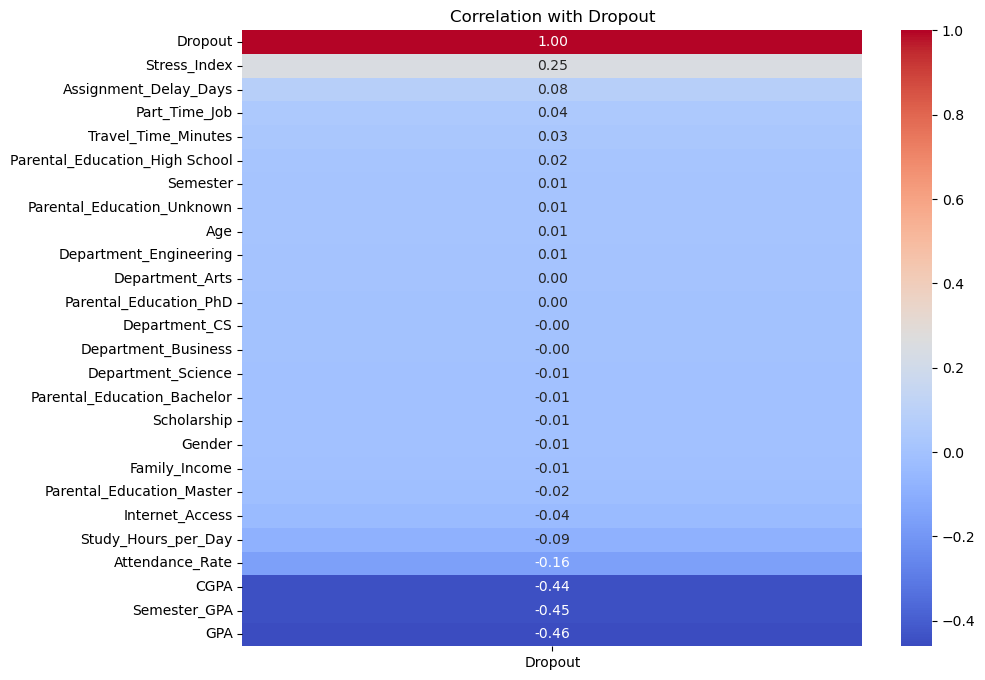

In [556]:
corr = df.corr(numeric_only=True)[["Dropout"]].sort_values(by="Dropout",ascending=False)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Dropout")
plt.show()

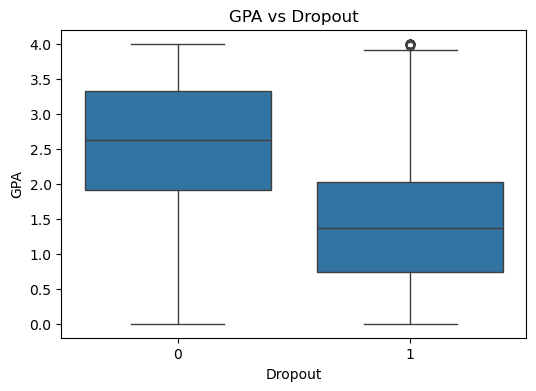

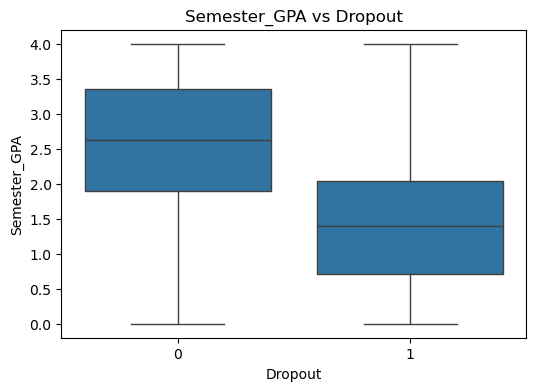

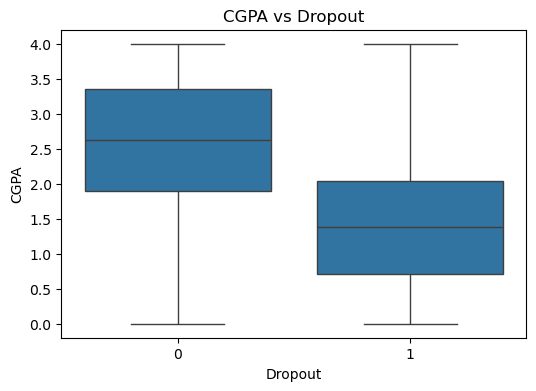

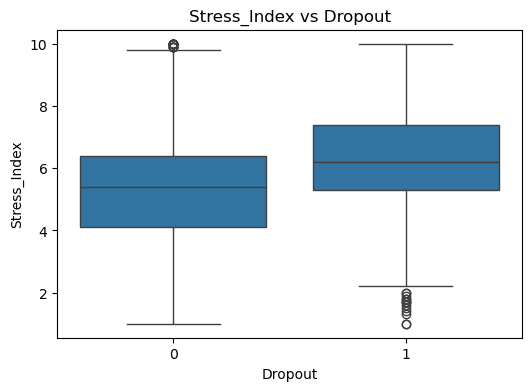

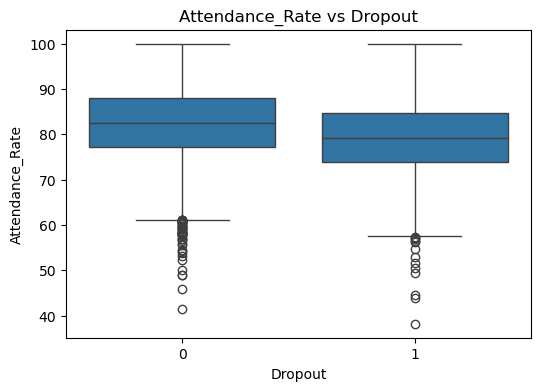

In [557]:
features = ["GPA", "Semester_GPA", "CGPA", "Stress_Index", "Attendance_Rate"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Dropout", y=col, data=df)
    plt.title(f"{col} vs Dropout")
    plt.show()

Check correlation between suspicious cols

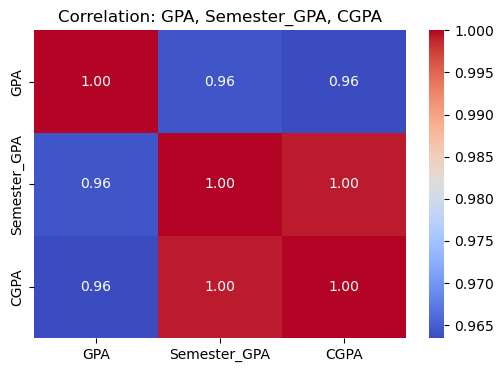

In [558]:
cols_corr = ["GPA", "Semester_GPA", "CGPA"]
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: GPA, Semester_GPA, CGPA")
plt.show()

Decided to delete columns based on correlation

In [559]:
cols_to_delete = ["Semester_GPA", "CGPA"]

df.drop(columns=cols_to_delete, inplace=True)

## Train-Test Split
##### The dataset was divided into training and testing sets to allow proper model evaluation on unseen data. Stratified splitting was applied to preserve the original class distribution of the target variable (Dropout) in both subsets.

In [560]:
X = df.drop(columns='Dropout')
y = df['Dropout']

In [561]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Feature Scaling
##### Feature scaling was applied using StandardScaler to standardize the numerical input variables. This step was especially important for Logistic Regression, as the model is sensitive to differences in feature scale.

In [562]:
cols_to_scale = [
    "Age",
    "Family_Income",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Stress_Index",
    "GPA"
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

## SMOTE
##### To address class imbalance in the training data, SMOTE (Synthetic Minority Oversampling Technique) was applied. This method generates synthetic examples of the minority class, helping the model learn dropout patterns more effectively.

In [563]:
# Wskaż które kolumny są binarne/kategoryczne (nie ciągłe)
categorical_cols = [col for col in X_train_scaled.columns if col not in cols_to_scale]

# Zamień nazwy kolumn na indeksy (SMOTENC wymaga indeksów)
categorical_indices = [X_train_scaled.columns.get_loc(col) for col in categorical_cols]

smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(X_train_scaled, y_train)

## Logistic Regression
##### Logistic Regression was used as the baseline classification model. It was trained on the scaled training data after applying SMOTE and then evaluated on the test set using classification metrics and ROC AUC. This model was chosen as a simple and interpretable approach for binary classification.

In [564]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [565]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

y_pred_train = model.predict(X_train_smote)
y_proba_train = model.predict_proba(X_train_smote)[:,1]



In [566]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\n===================================\n")
print(confusion_matrix(y_train_smote, y_pred_train))
print("ROC AUC:", roc_auc_score(y_train_smote, y_proba_train))

[[1215  314]
 [ 158  313]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1529
           1       0.50      0.66      0.57       471

    accuracy                           0.76      2000
   macro avg       0.69      0.73      0.70      2000
weighted avg       0.79      0.76      0.77      2000

ROC AUC: 0.8041446402808268


[[4888 1229]
 [1328 4789]]
ROC AUC: 0.878575959087158


In [577]:
model_sc = LogisticRegression(random_state=42, max_iter=1000)
model_sc.fit(X_train_scaled, y_train)

y_proba_sc = model_sc.predict_proba(X_test_scaled)[:, 1]
y_pred_sc = model_sc.predict(X_test_scaled)

y_pred_train_sc = model_sc.predict(X_train_scaled)
y_proba_train_sc = model_sc.predict_proba(X_train_scaled)[:,1]

print(confusion_matrix(y_test, y_pred_sc))
print(classification_report(y_test, y_pred_sc))
print("ROC AUC:", roc_auc_score(y_test, y_proba_sc))
print("\n===================================\n")
print(confusion_matrix(y_train, y_pred_train_sc))
print("ROC AUC:", roc_auc_score(y_train, y_proba_train_sc))

[[1439   90]
 [ 281  190]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.51       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000

ROC AUC: 0.8201744337014466


[[5723  394]
 [1126  757]]
ROC AUC: 0.8233326917462118


## XGBoost
##### XGBoost was used as a more advanced tree-based classification model. Unlike Logistic Regression, it was trained on the non-scaled data, as tree-based models do not require feature standardization. The model was first evaluated in its baseline form and then tuned using GridSearchCV with StratifiedKFold to improve its ability to identify students at risk of dropout.

In [567]:
model_xgb = XGBClassifier(eval_metric='error', random_state=42, scale_pos_weight=3.25)
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'error'


In [568]:
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

y_pred_xgb_train = model_xgb.predict(X_train)
y_proba_xgb_train = model_xgb.predict_proba(X_train)[:, 1]

In [569]:
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\n===================================\n")
print(confusion_matrix(y_train, y_pred_xgb_train))
print("ROC AUC:", roc_auc_score(y_train, y_proba_xgb_train))

[[1276  253]
 [ 202  269]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1529
           1       0.52      0.57      0.54       471

    accuracy                           0.77      2000
   macro avg       0.69      0.70      0.70      2000
weighted avg       0.78      0.77      0.78      2000

ROC AUC: 0.7850210856213697


[[5877  240]
 [  22 1861]]
ROC AUC: 0.997818343331761


In [570]:
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# parameters = {
#     'max_depth': range (2, 10, 1),
#     'n_estimators': [10, 20, 50, 75, 100, 150, 200],
#     'learning_rate': [0.1, 0.05, 0.01],
#     'colsample_bytree': [0.8, 0.9, 1]
# }

# grid_obj = GridSearchCV(estimator=model_xgb, param_grid=parameters, scoring='recall', cv=skf)
# grid_fit = grid_obj.fit(X_train, y_train)

In [571]:
# grid_fit.best_params_

In [572]:
# best_clf = grid_fit.best_estimator_
# y_pred_best = best_clf.predict(X_test)
# y_proba_best = best_clf.predict_proba(X_test)[:, 1]

In [573]:
# print(confusion_matrix(y_test, y_pred_best))
# print(classification_report(y_test, y_pred_best))
# print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

## Conclusion

##### The final comparison confirms that Logistic Regression outperformed XGBoost (basic) across all key metrics for the dropout class (1). Logistic Regression achieved 0.52 precision, 0.65 recall, and 0.58 F1-score, while XGBoost reached 0.52 precision, 0.54 recall, and 0.53 F1-score. Logistic Regression identified significantly more students at risk of dropout while maintaining the same precision level. Overall accuracy was 0.78 for Logistic Regression versus 0.77 for XGBoost, and macro average F1-score was 0.71 versus 0.69 respectively. The absence of overfitting in Logistic Regression (train ROC AUC 0.830 vs test ROC AUC 0.819) further supports it as the stronger and more reliable model for this dataset.

##### In the context of dropout prediction, recall is the most critical metric — a missed at-risk student means no intervention. While the updated model shows a lower recall compared to the initial version, this reflects a more reliable result rather than a regression. The previous higher recall (0.76) was partly an artifact of applying standard SMOTE to binary and one-hot encoded columns, which generated synthetic samples with invalid non-binary values, artificially inflating minority class detection. Replacing SMOTE with SMOTENC resolved this issue by correctly handling binary and categorical features during oversampling.

##### XGBoost was evaluated in its basic form only. GridSearchCV tuning was explored during development but was ultimately set aside, as the basic XGBoost model already exhibited significant overfitting (train ROC AUC 0.999 vs test ROC AUC 0.776), suggesting that the dataset size and structure favour a simpler linear model over a complex tree-based approach.

---

##### **Note — Initial results (before preprocessing improvements):**
##### The original pipeline used median imputation, standard SMOTE applied to all features including binary columns, StandardScaler on all columns without exception, and ordinal encoding for Parental_Education. Under those conditions, Logistic Regression achieved 0.47 precision, 0.76 recall, and 0.58 F1-score, while tuned XGBoost reached 0.44 precision, 0.75 recall, and 0.56 F1-score. The higher recall in the original version should be interpreted with caution — it was produced under a flawed preprocessing setup. The updated pipeline applies KNN imputation, SMOTENC for correct handling of categorical and binary features, selective scaling of continuous variables only, OHE for Parental_Education, and removal of highly correlated GPA features (Semester_GPA, CGPA). These changes improve the methodological correctness of the model at the cost of a modest reduction in recall.


In [574]:
print(f"XGBoost (basic) \n\n {classification_report(y_test, y_pred_xgb)}\n {'='*100}\n\nLogistic Regression \n\n {classification_report(y_test, y_pred)}")

XGBoost (basic) 

               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1529
           1       0.52      0.57      0.54       471

    accuracy                           0.77      2000
   macro avg       0.69      0.70      0.70      2000
weighted avg       0.78      0.77      0.78      2000


Logistic Regression 

               precision    recall  f1-score   support

           0       0.88      0.79      0.84      1529
           1       0.50      0.66      0.57       471

    accuracy                           0.76      2000
   macro avg       0.69      0.73      0.70      2000
weighted avg       0.79      0.76      0.77      2000

